# 🎧 Audio Language Model — MAD Data Exploration

**Dataset:** MAD (Military Audio Dataset)
**Goal:** Understand MAD's class distribution, audio characteristics, and mel spectrogram
features, and verify that the existing ALM preprocessing pipeline (built for ESC-50 /
UrbanSound8K) applies cleanly to MAD before starting the retraining phase.

This notebook mirrors the structure, plotting style, and level of detail of the original
ALM Data Exploration notebook (ESC-50 / UrbanSound8K). It does **not** introduce a new
exploration methodology, and it does **not** change the ALM preprocessing configuration —
it only checks whether MAD is compatible with it.

---
**Sections**
1. [Setup & Imports](#1-setup)
2. [MAD Exploration](#2-mad)
3. [Audio Statistics](#3-stats)
4. [MAD vs. ALM Preprocessing Requirements](#4-comparison)
5. [Mel Spectrogram Visualization](#5-melspec)
6. [Preprocessing Deep-Dive & Tensor Shape](#6-deepdive)
7. [Summary & Preprocessing Notes](#7-summary)

---
## 1. Setup & Imports <a id='1-setup'></a>

In [19]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from collections import Counter
from tqdm import tqdm

# ── Project paths ────────────────────────────────────────────────────────────
# This notebook lives in <project>/data/notebooks/. MAD lives in
# <project>/data/raw/MAD_dataset/{training,test}/ with training.csv / test.csv
# as siblings of those two folders (as opposed to ESC-50/UrbanSound8K, which
# sat directly under data/raw/<name>/). Adjust NOTEBOOK_DIR manually if you
# run this notebook from a different working directory.
NOTEBOOK_DIR = Path.cwd()
DATA_DIR     = NOTEBOOK_DIR.parent           # .../data
ROOT         = DATA_DIR.parent               # project root
DATA_RAW     = DATA_DIR / 'raw'

MAD_DIR        = DATA_RAW / 'MAD_dataset'
MAD_TRAIN_META = MAD_DIR / 'training.csv'
MAD_TEST_META  = MAD_DIR / 'test.csv'
MAD_TRAIN_DIR  = MAD_DIR / 'training'
MAD_TEST_DIR   = MAD_DIR / 'test'

print('librosa  version:', librosa.__version__)
print('pandas   version:', pd.__version__)
print('numpy    version:', np.__version__)

librosa  version: 0.11.0
pandas   version: 2.3.3
numpy    version: 2.2.6


In [20]:
# ── Path verification ────────────────────────────────────────────────────────
for p, name in [
    (MAD_DIR,        'MAD root'),
    (MAD_TRAIN_DIR,  'MAD training/ audio'),
    (MAD_TEST_DIR,   'MAD test/ audio'),
    (MAD_TRAIN_META, 'MAD training.csv'),
    (MAD_TEST_META,  'MAD test.csv'),
]:
    status = '✅' if p.exists() else '❌ NOT FOUND'
    print(f"{status}  {name:25s}  →  {p}")

✅  MAD root                   →  c:\Users\shara\Desktop\alm\ALM\data\raw\MAD_dataset
✅  MAD training/ audio        →  c:\Users\shara\Desktop\alm\ALM\data\raw\MAD_dataset\training
✅  MAD test/ audio            →  c:\Users\shara\Desktop\alm\ALM\data\raw\MAD_dataset\test
✅  MAD training.csv           →  c:\Users\shara\Desktop\alm\ALM\data\raw\MAD_dataset\training.csv
✅  MAD test.csv               →  c:\Users\shara\Desktop\alm\ALM\data\raw\MAD_dataset\test.csv


In [21]:
# ── Plot style (kept identical to the ESC-50/UrbanSound8K notebook) ──────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f14',
    'axes.facecolor'   : '#16161e',
    'axes.edgecolor'   : '#2a2a3a',
    'axes.labelcolor'  : '#c8c8d8',
    'axes.titlecolor'  : '#e8e8f0',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 10,
    'xtick.color'      : '#888899',
    'ytick.color'      : '#888899',
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'grid.color'       : '#2a2a3a',
    'grid.linewidth'   : 0.6,
    'text.color'       : '#c8c8d8',
    'font.family'      : 'monospace',
    'figure.dpi'       : 120,
})

# Colour palette — MAD-specific
MAD_COLOR = '#7ee0b0'   # muted military green for MAD
ACCENT    = '#a78bfa'   # lavender accent (kept from original notebook)
GRAD_MAD  = plt.cm.Greens

FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Plot style configured.')
print('Figures will be saved to:', FIGURES_DIR)

Plot style configured.
Figures will be saved to: c:\Users\shara\Desktop\alm\ALM\outputs\figures


---
## 2. MAD Exploration <a id='2-mad'></a>

### 2.1 Inspect raw structure

MAD does not necessarily share ESC-50's or UrbanSound8K's layout, so nothing about the
label column, split structure, or naming is assumed here — it's detected from the actual
CSVs and folders.

In [22]:
mad_train_df = pd.read_csv(MAD_TRAIN_META)
mad_test_df  = pd.read_csv(MAD_TEST_META)

# Drop a stray unnamed index column if the CSV was exported with one
for df in (mad_train_df, mad_test_df):
    unnamed = [c for c in df.columns if c.startswith('Unnamed')]
    df.drop(columns=unnamed, inplace=True, errors='ignore')

print('=== training.csv ===')
print(f'Shape  : {mad_train_df.shape}')
print(f'Columns: {list(mad_train_df.columns)}')
display(mad_train_df.head())

print('\n=== test.csv ===')
print(f'Shape  : {mad_test_df.shape}')
print(f'Columns: {list(mad_test_df.columns)}')
display(mad_test_df.head())

=== training.csv ===
Shape  : (6429, 4)
Columns: ['path', 'label', 'youtube title', 'youtube url']


,path,label,youtube title,youtube url
0,training/398/0.wav,3,"US Army, NATO. Powerful M1A2 Abrams and TR-85 ...",https://www.youtube.com/watch?v=Oh4q6ck6ufc&t=1s
1,training/398/1.wav,3,"US Army, NATO. Powerful M1A2 Abrams and TR-85 ...",https://www.youtube.com/watch?v=Oh4q6ck6ufc&t=1s
2,training/398/2.wav,3,"US Army, NATO. Powerful M1A2 Abrams and TR-85 ...",https://www.youtube.com/watch?v=Oh4q6ck6ufc&t=1s
3,training/398/3.wav,3,"US Army, NATO. Powerful M1A2 Abrams and TR-85 ...",https://www.youtube.com/watch?v=Oh4q6ck6ufc&t=1s
4,training/398/4.wav,3,"US Army, NATO. Powerful M1A2 Abrams and TR-85 ...",https://www.youtube.com/watch?v=Oh4q6ck6ufc&t=1s



=== test.csv ===
Shape  : (1037, 4)
Columns: ['path', 'label', 'youtube title', 'youtube url']


,path,label,youtube title,youtube url
0,test/227/0.wav,6,USAF. The World's Most Powerful F-22 Raptor Fi...,https://www.youtube.com/watch?v=GIeHCynGoAU&t=...
1,test/227/1.wav,6,USAF. The World's Most Powerful F-22 Raptor Fi...,https://www.youtube.com/watch?v=GIeHCynGoAU&t=...
2,test/227/10.wav,6,USAF. The World's Most Powerful F-22 Raptor Fi...,https://www.youtube.com/watch?v=GIeHCynGoAU&t=...
3,test/227/11.wav,6,USAF. The World's Most Powerful F-22 Raptor Fi...,https://www.youtube.com/watch?v=GIeHCynGoAU&t=...
4,test/227/12.wav,6,USAF. The World's Most Powerful F-22 Raptor Fi...,https://www.youtube.com/watch?v=GIeHCynGoAU&t=...


In [23]:
# ── Detect the label / filename columns programmatically ─────────────────────
CANDIDATE_LABEL_COLS = ['label', 'class', 'category', 'target']
CANDIDATE_PATH_COLS  = ['path', 'filename', 'file', 'file_path', 'slice_file_name']

def detect_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f'Could not find any of {candidates} in columns {list(df.columns)}')

MAD_LABEL_COL = detect_column(mad_train_df, CANDIDATE_LABEL_COLS)
MAD_PATH_COL  = detect_column(mad_train_df, CANDIDATE_PATH_COLS)

print(f'Detected label column   : "{MAD_LABEL_COL}"')
print(f'Detected filename column: "{MAD_PATH_COL}"')

# ── Merge train/test with a split tag for combined stats ─────────────────────
mad_train_df = mad_train_df.copy()
mad_test_df  = mad_test_df.copy()
mad_train_df['split'] = 'training'
mad_test_df['split']  = 'test'
mad_df = pd.concat([mad_train_df, mad_test_df], ignore_index=True)

print(f'\nCombined MAD metadata shape: {mad_df.shape}')

Detected label column   : "label"
Detected filename column: "path"

Combined MAD metadata shape: (7466, 5)


In [24]:
labels = mad_df[MAD_LABEL_COL]

MAD_CLASS_NAMES = {
    0: "Communication",
    1: "Gunshot",
    2: "Footsteps",
    3: "Shelling",
    4: "Vehicle",
    5: "Helicopter",
    6: "Fighter",
}

# Single-label vs multi-label: a clip is multi-label only if the same
# filename/path appears more than once with different label values.
dup_paths = mad_df[MAD_PATH_COL][mad_df[MAD_PATH_COL].duplicated(keep=False)]
is_multilabel = False
if len(dup_paths) > 0:
    dup_check = mad_df[mad_df[MAD_PATH_COL].isin(dup_paths.unique())]
    labels_per_path = dup_check.groupby(MAD_PATH_COL)[MAD_LABEL_COL].nunique()
    is_multilabel = (labels_per_path > 1).any()

print('=== MAD Dataset Summary ===')
print(f'  Total clips        : {len(mad_df)}')
print(f'  Training clips     : {len(mad_train_df)}')
print(f'  Test clips         : {len(mad_test_df)}')
print(f'  Unique classes     : {labels.nunique()}')
print(f'  Class labels       : {sorted(labels.unique().tolist())}')
print(f'  Class names        : {[MAD_CLASS_NAMES.get(c, str(c)) for c in sorted(labels.unique().tolist())]}')
print(f'  Label type         : {"multi-label" if is_multilabel else "single-label"}')
print(f'  Missing values     : {mad_df.isna().sum().sum()}')
print(f'  Duplicate paths    : {mad_df[MAD_PATH_COL].duplicated().sum()}')

if is_multilabel:
    print('\n  ⚠ MAD contains clips with more than one label — treat as multi-label.')
else:
    print('\n  ✓ Each MAD clip maps to exactly one label — MAD is single-label.')

print(f'\n  Note: Mapped numeric class labels to human-readable names using MAD_CLASS_NAMES.')

=== MAD Dataset Summary ===
  Total clips        : 7466
  Training clips     : 6429
  Test clips         : 1037
  Unique classes     : 7
  Class labels       : [0, 1, 2, 3, 4, 5, 6]
  Class names        : ['Communication', 'Gunshot', 'Footsteps', 'Shelling', 'Vehicle', 'Helicopter', 'Fighter']
  Label type         : single-label
  Missing values     : 372
  Duplicate paths    : 0

  ✓ Each MAD clip maps to exactly one label — MAD is single-label.

  Note: Mapped numeric class labels to human-readable names using MAD_CLASS_NAMES.


### 2.2 Class distribution

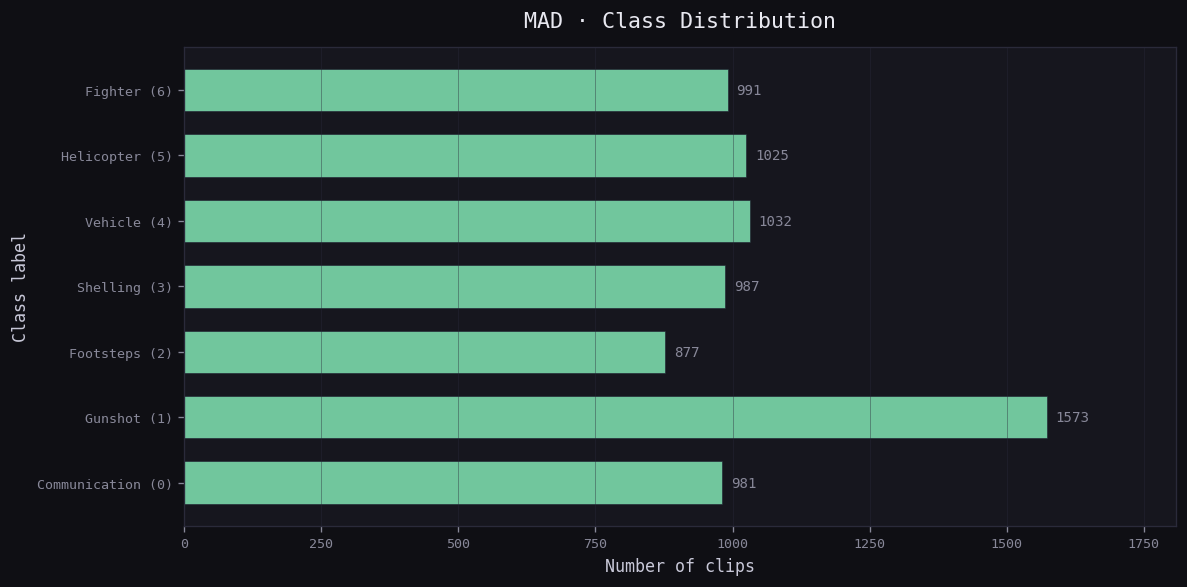

Saved → outputs/figures/mad_class_distribution.png


In [25]:
class_counts = mad_df[MAD_LABEL_COL].value_counts().sort_index()

y_labels = [f"{MAD_CLASS_NAMES.get(c, str(c))} ({c})" for c in class_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(y_labels, class_counts.values,
               color=MAD_COLOR, alpha=0.88, height=0.65,
               edgecolor='#1e1e2e', linewidth=0.4)

for bar, val in zip(bars, class_counts.values):
    ax.text(val + max(class_counts.values) * 0.01, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=8.5, color='#888899')

ax.set_xlabel('Number of clips')
ax.set_ylabel('Class label')
ax.set_title('MAD · Class Distribution', pad=12)
ax.set_xlim(0, class_counts.max() * 1.15)
ax.grid(axis='x', alpha=0.4)
fig.tight_layout()
plt.savefig(FIGURES_DIR / 'mad_class_distribution.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved → outputs/figures/mad_class_distribution.png')

In [26]:
# ── Class balance statistics ──────────────────────────────────────────────────
min_count   = class_counts.min()
max_count   = class_counts.max()
mean_count  = class_counts.mean()
median_count = class_counts.median()
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

most_represented  = class_counts.idxmax()
least_represented = class_counts.idxmin()

print('=== MAD Class Balance ===')
print(f'  Minimum class count : {min_count}')
print(f'  Maximum class count : {max_count}')
print(f'  Mean class count    : {mean_count:.1f}')
print(f'  Median class count  : {median_count:.1f}')
print(f'  Imbalance ratio     : {imbalance_ratio:.2f}x  (max / min)')
print(f'  Most represented    : {MAD_CLASS_NAMES.get(most_represented, str(most_represented))} ({most_represented})  ({max_count} clips)')
print(f'  Least represented   : {MAD_CLASS_NAMES.get(least_represented, str(least_represented))} ({least_represented})  ({min_count} clips)')

# This is descriptive only — no class weighting / oversampling is implemented here.
if imbalance_ratio >= 3:
    print('\n  Observation: MAD shows significant class imbalance. '
          'This should be considered during model training.')
else:
    print('\n  Observation: MAD classes are relatively balanced. '
          'No major class imbalance is observed.')

=== MAD Class Balance ===
  Minimum class count : 877
  Maximum class count : 1573
  Mean class count    : 1066.6
  Median class count  : 991.0
  Imbalance ratio     : 1.79x  (max / min)
  Most represented    : Gunshot (1)  (1573 clips)
  Least represented   : Footsteps (2)  (877 clips)

  Observation: MAD classes are relatively balanced. No major class imbalance is observed.


### 2.3 Predefined train / test split

MAD ships pre-split `training.csv` and `test.csv` files rather than the fold-based
splits used by ESC-50/UrbanSound8K. No validation split is provided — none is
fabricated here.

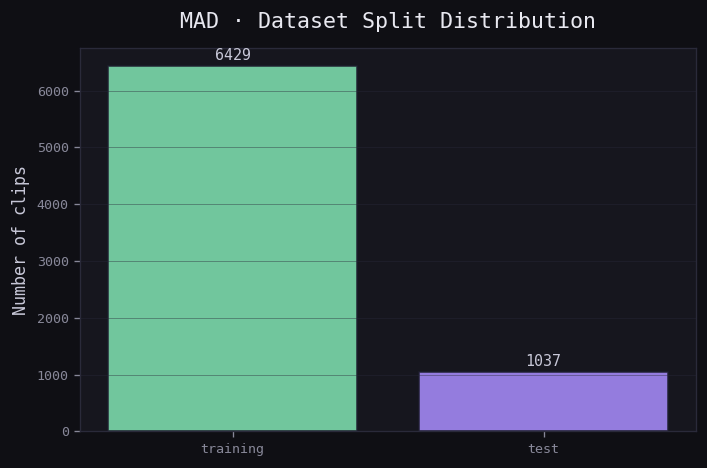

No predefined validation split detected — only training/test.

Class counts per split:


split,test,training
label,,
Communication (0),207,774
Gunshot (1),280,1293
Footsteps (2),104,773
Shelling (3),104,883
Vehicle (4),122,910
Helicopter (5),91,934
Fighter (6),129,862


In [27]:
split_counts = mad_df['split'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(split_counts.index, split_counts.values,
              color=[MAD_COLOR, ACCENT], alpha=0.88, edgecolor='#1e1e2e')
for bar, val in zip(bars, split_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(split_counts.values)*0.01,
            str(val), ha='center', va='bottom', fontsize=9, color='#c8c8d8')
ax.set_ylabel('Number of clips')
ax.set_title('MAD · Dataset Split Distribution', pad=12)
ax.grid(axis='y', alpha=0.4)
fig.tight_layout()
plt.savefig(FIGURES_DIR / 'mad_split_distribution.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

print('No predefined validation split detected — only training/test.')

# Class distribution consistency across splits
split_class = pd.crosstab(mad_df[MAD_LABEL_COL], mad_df['split'])
split_class.index = split_class.index.map(lambda c: f"{MAD_CLASS_NAMES.get(c, str(c))} ({c})")
print('\nClass counts per split:')
display(split_class)

---
## 3. Audio File Statistics <a id='3-stats'></a>

In [28]:
# ── Scan a sample of files (set FULL_SCAN=True to scan everything) ───────────
FULL_SCAN = False
SAMPLE_N  = 150   # adjust upward if MAD is much larger than ESC-50/UrbanSound8K

sample_rows = mad_df if (FULL_SCAN or len(mad_df) <= SAMPLE_N) \
              else mad_df.sample(SAMPLE_N, random_state=42)

mad_stats = []
missing_or_corrupt = []

for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc='Scanning MAD'):
    fpath = MAD_DIR / row[MAD_PATH_COL]
    if not fpath.exists():
        missing_or_corrupt.append(str(row[MAD_PATH_COL]))
        continue
    try:
        info = sf.info(str(fpath))
        mad_stats.append({
            'filename'   : row[MAD_PATH_COL],
            'label'      : row[MAD_LABEL_COL],
            'split'      : row['split'],
            'sample_rate': info.samplerate,
            'channels'   : info.channels,
            'duration_s' : info.duration,
            'frames'     : info.frames,
        })
    except Exception as e:
        missing_or_corrupt.append(str(row[MAD_PATH_COL]))
        print(f'  ⚠ Could not read {fpath.name}: {e}')

mad_stats_df = pd.DataFrame(mad_stats)
print(f'\nScanned successfully : {len(mad_stats_df)} / {len(sample_rows)}')
print(f'Missing / unreadable : {len(missing_or_corrupt)}')
if len(mad_stats_df) > 0:
    display(mad_stats_df[['sample_rate', 'channels', 'duration_s']].describe().round(3))
else:
    print('⚠ No audio files could be read. Check MAD_DIR / the path column values.')

Scanning MAD: 100%|██████████| 150/150 [00:00<00:00, 4507.97it/s]


Scanned successfully : 150 / 150
Missing / unreadable : 0


,sample_rate,channels,duration_s
count,150.0,150.0,150.000
mean,16000.0,1.0,5.187
std,0.0,0.0,2.448
min,16000.0,1.0,1.000
25%,16000.0,1.0,3.019
50%,16000.0,1.0,5.000
75%,16000.0,1.0,7.000
max,16000.0,1.0,10.000


### 3.1 Audio statistics plots

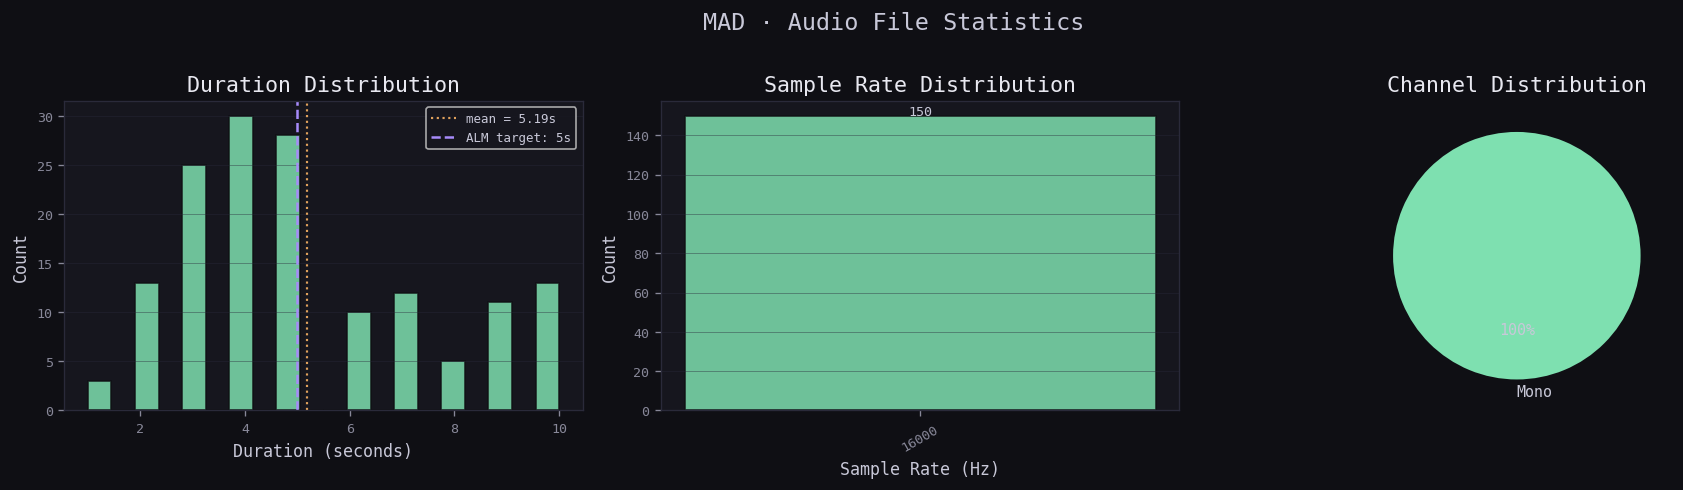

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('MAD · Audio File Statistics', fontsize=14, y=1.01)

# Duration distribution — no assumption about a 4s/5s clip length; MAD's own
# statistics decide the histogram range. The ALM 5s preprocessing target is
# only shown as a reference line, not as a claim about MAD itself.
ax = axes[0]
if len(mad_stats_df) > 0:
    ax.hist(mad_stats_df['duration_s'], bins=20, color=MAD_COLOR, alpha=0.85, edgecolor='#0f0f14')
    ax.axvline(mad_stats_df['duration_s'].mean(), color='#e0a15c', lw=1.3, linestyle=':',
               label=f"mean = {mad_stats_df['duration_s'].mean():.2f}s")
ax.axvline(5.0, color=ACCENT, lw=1.5, linestyle='--', label='ALM target: 5s')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Duration Distribution')
ax.legend(fontsize=7.5)
ax.grid(axis='y', alpha=0.4)

# Sample rate distribution
ax = axes[1]
if len(mad_stats_df) > 0:
    sr_counts = mad_stats_df['sample_rate'].value_counts().sort_index()
    ax.bar(sr_counts.index.astype(str), sr_counts.values, color=MAD_COLOR, alpha=0.85,
           edgecolor='#0f0f14')
    for i, (label, val) in enumerate(zip(sr_counts.index.astype(str), sr_counts.values)):
        ax.text(i, val + 0.5, str(val), ha='center', fontsize=8, color='#c8c8d8')
ax.set_xlabel('Sample Rate (Hz)')
ax.set_ylabel('Count')
ax.set_title('Sample Rate Distribution')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.4)

# Channel distribution
ax = axes[2]
if len(mad_stats_df) > 0:
    ch_counts = mad_stats_df['channels'].value_counts()
    ch_labels = ['Mono' if c == 1 else 'Stereo' if c == 2 else str(c) for c in ch_counts.index]
    ax.pie(ch_counts.values, labels=ch_labels, autopct='%1.0f%%',
           colors=[MAD_COLOR, ACCENT, '#e0a15c'][:len(ch_counts)],
           startangle=90, textprops={'fontsize': 9})
ax.set_title('Channel Distribution')

fig.tight_layout()
plt.savefig(FIGURES_DIR / 'mad_audio_stats.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 4. MAD vs. ALM Preprocessing Requirements <a id='4-comparison'></a>

Rather than a two-dataset (ESC-50 vs UrbanSound8K) comparison, this notebook compares
MAD's *actual* characteristics against the ALM pipeline's fixed target format. Values below
are populated from the statistics computed above — nothing here is invented.

In [30]:
def fmt_sr(stats_df):
    if len(stats_df) == 0:
        return 'unknown (no files read)'
    srs = sorted(stats_df['sample_rate'].unique().tolist())
    return ', '.join(f'{sr} Hz' for sr in srs)

def fmt_channels(stats_df):
    if len(stats_df) == 0:
        return 'unknown'
    chs = sorted(stats_df['channels'].unique().tolist())
    names = {1: 'Mono', 2: 'Stereo'}
    return ', '.join(names.get(c, str(c)) for c in chs)

comparison = pd.DataFrame({
    'Property'   : ['Total clips', 'Classes', 'Duration', 'Sample rate(s)',
                    'Channels', 'Label type', 'Class balance',
                    'Mel bins', 'FFT', 'Hop length'],
    'MAD'        : [
        f'{len(mad_df)}',
        f'{mad_df[MAD_LABEL_COL].nunique()}',
        (f'{mad_stats_df["duration_s"].min():.2f}s – {mad_stats_df["duration_s"].max():.2f}s'
         if len(mad_stats_df) > 0 else 'unknown'),
        fmt_sr(mad_stats_df),
        fmt_channels(mad_stats_df),
        'multi-label' if is_multilabel else 'single-label',
        f'{imbalance_ratio:.2f}x imbalance ratio',
        '—', '—', '—',
    ],
    'ALM Target' : ['—', '—', '5 sec', '16 kHz', 'Mono', '—', '—', '128', '1024', '512'],
})
comparison.set_index('Property', inplace=True)
display(comparison)

,MAD,ALM Target
Property,,
Total clips,7466,—
Classes,7,—
Duration,1.00s – 10.00s,5 sec
Sample rate(s),16000 Hz,16 kHz
Channels,Mono,Mono
Label type,single-label,—
Class balance,1.79x imbalance ratio,—
Mel bins,—,128
FFT,—,1024


---
## 5. Mel Spectrogram Visualization <a id='5-melspec'></a>

In [31]:
# ── Mel spectrogram helpers — SAME ALM preprocessing configuration ───────────
# These values are the existing ALM project config and are NOT changed here.
TARGET_SR   = 16_000
TARGET_DUR  = 5.0          # seconds
N_FFT       = 1024
HOP_LENGTH  = 512
N_MELS      = 128

def load_and_normalize(filepath: str,
                        sr: int = TARGET_SR,
                        duration: float = TARGET_DUR) -> np.ndarray:
    """Load audio, convert to mono, resample, pad/trim to fixed duration."""
    y, orig_sr = librosa.load(filepath, sr=sr, mono=True)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    else:
        y = y[:target_len]
    return y


def compute_melspec(y: np.ndarray, sr: int = TARGET_SR) -> np.ndarray:
    """Compute log-scaled mel spectrogram."""
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    return librosa.power_to_db(mel, ref=np.max)


print('Helper functions defined (ALM config, unchanged).')
print(f'  TARGET_SR  = {TARGET_SR} Hz')
print(f'  DURATION   = {TARGET_DUR} s')
print(f'  N_MELS     = {N_MELS}')
print(f'  N_FFT      = {N_FFT}')
print(f'  HOP_LENGTH = {HOP_LENGTH}')

Helper functions defined (ALM config, unchanged).
  TARGET_SR  = 16000 Hz
  DURATION   = 5.0 s
  N_MELS     = 128
  N_FFT      = 1024
  HOP_LENGTH = 512


In [32]:
# ── Select representative MAD classes deterministically ───────────────────────
available_labels = sorted(mad_df[MAD_LABEL_COL].unique().tolist())
N_SAMPLE_CLASSES = 6

if len(available_labels) <= N_SAMPLE_CLASSES:
    SAMPLE_CLASSES_MAD = available_labels
else:
    # Evenly spaced picks across the sorted label list → reproducible, no randomness.
    idxs = np.linspace(0, len(available_labels) - 1, N_SAMPLE_CLASSES).round().astype(int)
    SAMPLE_CLASSES_MAD = sorted({available_labels[i] for i in idxs})

print(f'Representative MAD classes selected for visualization: {SAMPLE_CLASSES_MAD}')

Representative MAD classes selected for visualization: [0, 1, 2, 4, 5, 6]


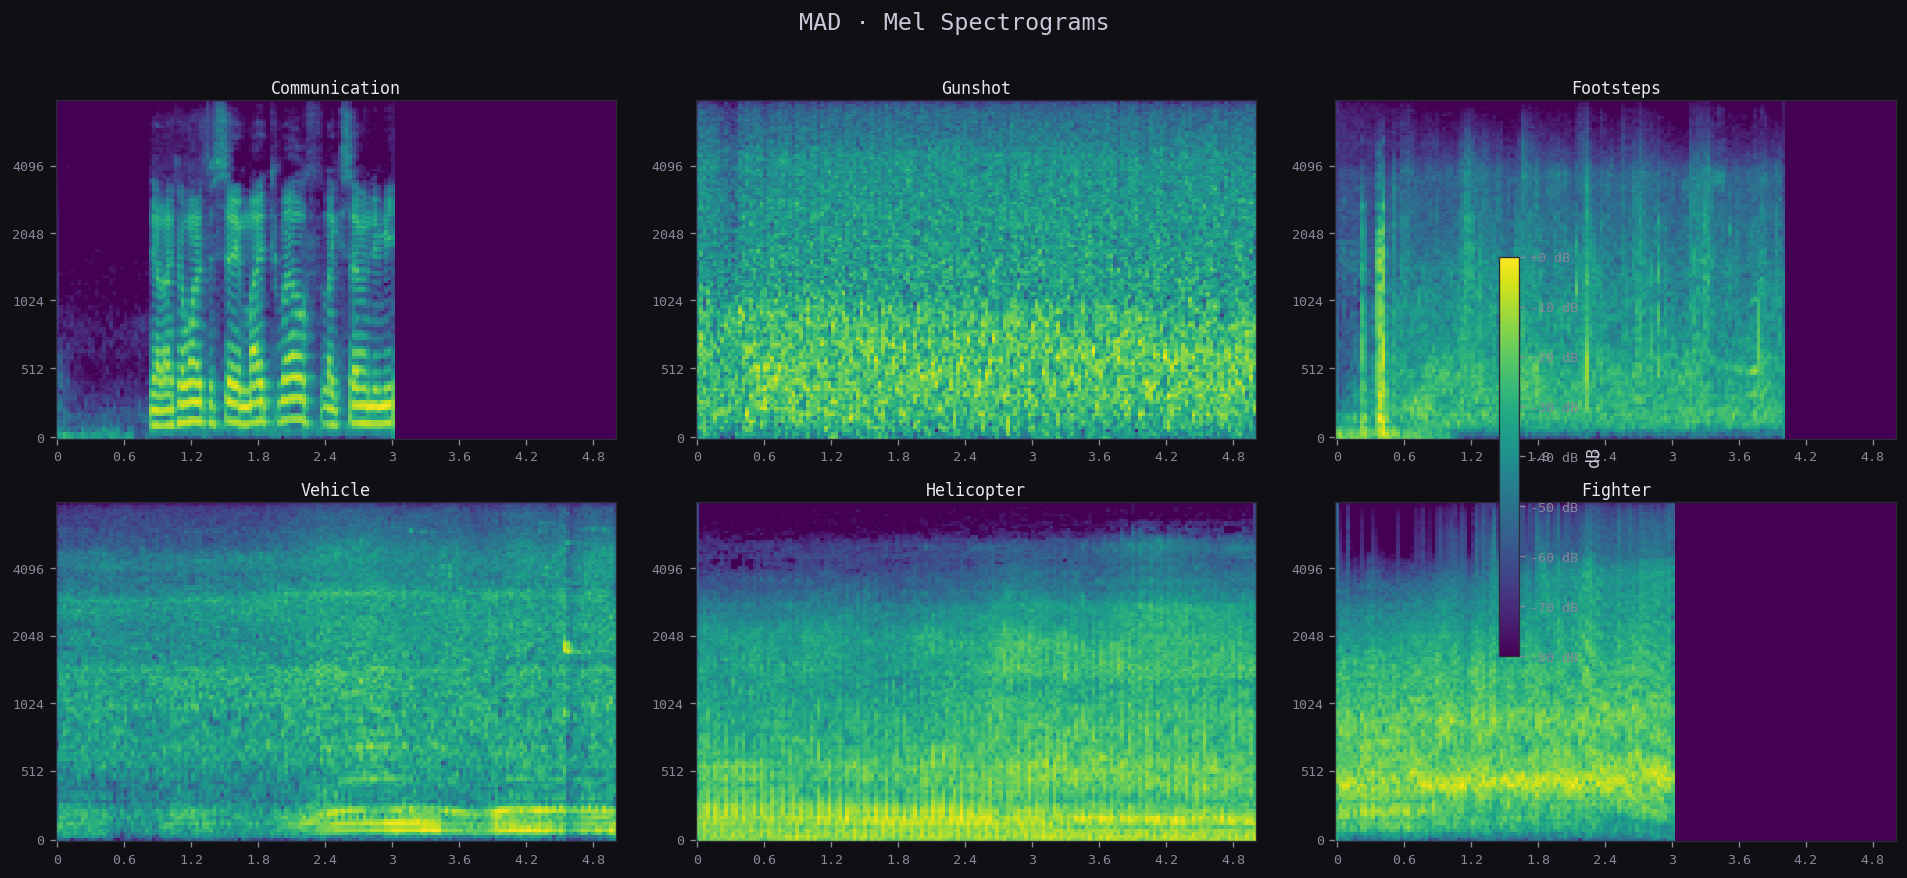

In [33]:
n_classes_shown = len(SAMPLE_CLASSES_MAD)
n_cols = 3
n_rows = int(np.ceil(n_classes_shown / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.6 * n_rows))
fig.suptitle('MAD · Mel Spectrograms', fontsize=14, y=1.01)
axes_flat = np.atleast_1d(axes).flatten()

img = None
for ax, cls in zip(axes_flat, SAMPLE_CLASSES_MAD):
    candidates = mad_df[mad_df[MAD_LABEL_COL] == cls]
    plotted = False
    for _, row in candidates.sample(min(len(candidates), 10), random_state=42).iterrows():
        fpath = MAD_DIR / row[MAD_PATH_COL]
        if not fpath.exists():
            continue
        try:
            y = load_and_normalize(str(fpath))
            mel_db = compute_melspec(y)
            img = librosa.display.specshow(
                mel_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
                x_axis='time', y_axis='mel', ax=ax, cmap='viridis'
            )
            cls_name = MAD_CLASS_NAMES.get(cls, f'Class {cls}')
            ax.set_title(cls_name, fontsize=10, pad=4)
            ax.set_xlabel('')
            ax.set_ylabel('')
            plotted = True
            break
        except Exception as e:
            continue
    if not plotted:
        cls_name = MAD_CLASS_NAMES.get(cls, f'Class {cls}')
        ax.set_title(f'{cls_name}\n[no readable sample]', fontsize=9)
        ax.text(0.5, 0.5, 'no audio found', transform=ax.transAxes, ha='center', fontsize=8)

# Hide any unused subplot axes
for ax in axes_flat[n_classes_shown:]:
    ax.axis('off')

if img is not None:
    fig.colorbar(img, ax=axes_flat[:n_classes_shown].tolist(), format='%+2.0f dB',
                 shrink=0.6, label='dB')
fig.tight_layout()
plt.savefig(FIGURES_DIR / 'mad_mel_spectrograms.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 6. Preprocessing Deep-Dive & Tensor Shape <a id='6-deepdive'></a>

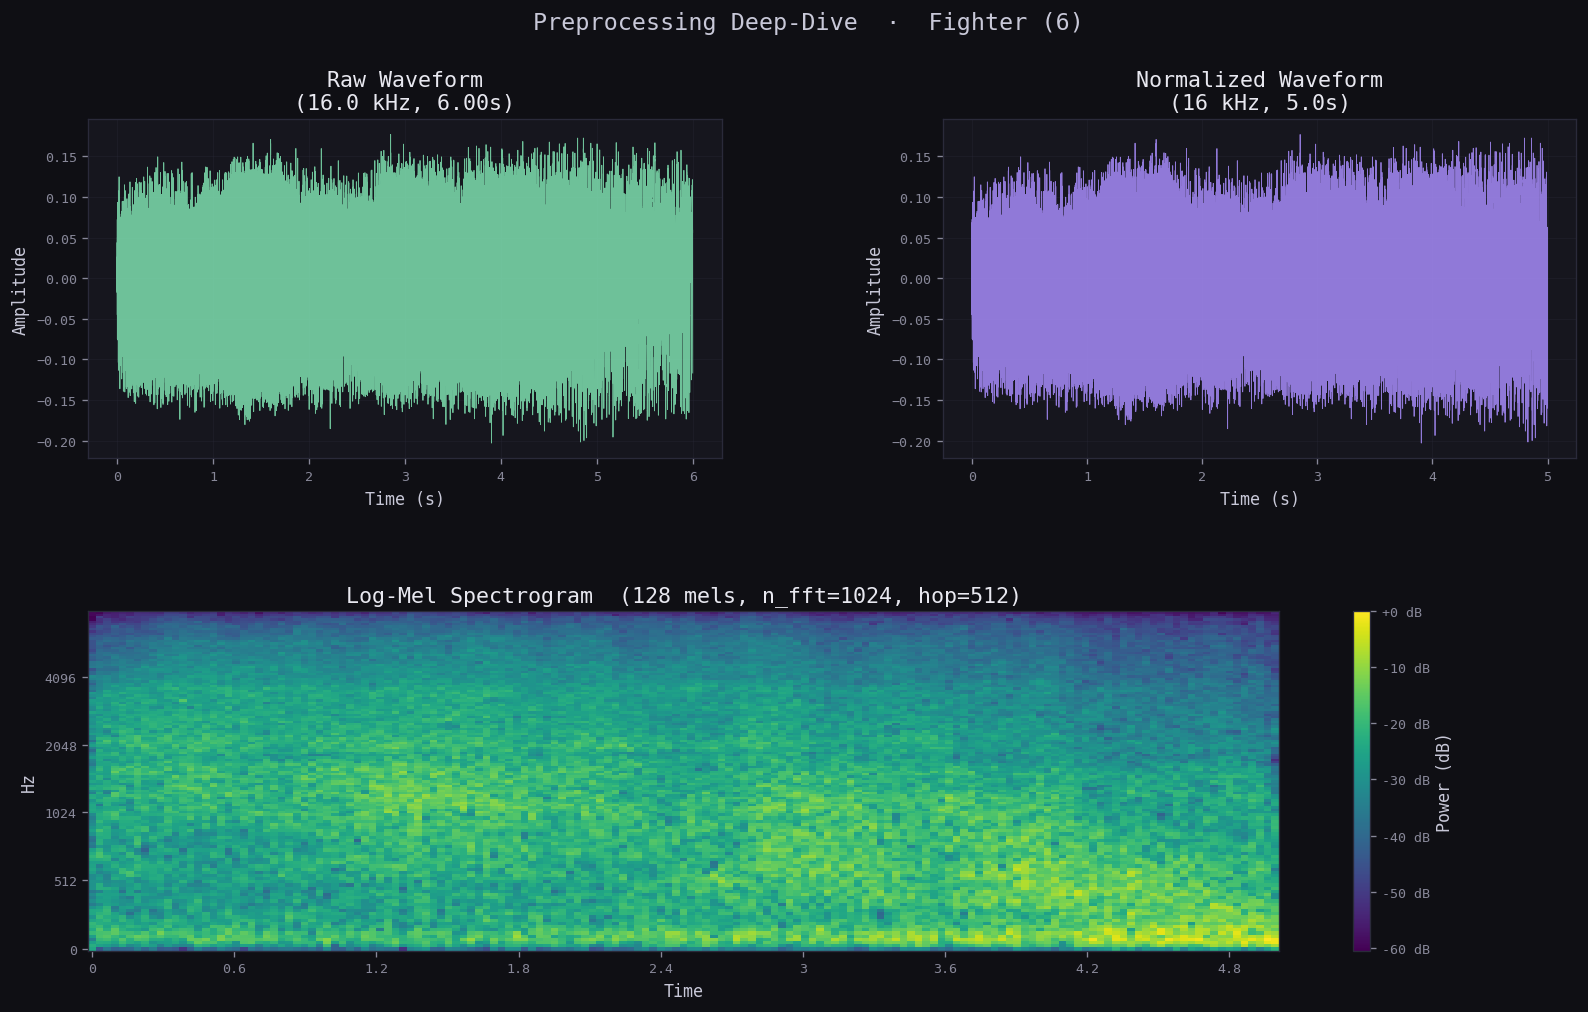

Sample: training/350/2.wav  |  Fighter (6)


In [34]:
# ── Deep-dive: effect of preprocessing on a single MAD clip ───────────────────
sample_row  = None
sample_path = None
for _, row in mad_df.sample(min(len(mad_df), 30), random_state=7).iterrows():
    candidate = MAD_DIR / row[MAD_PATH_COL]
    if candidate.exists():
        sample_row = row
        sample_path = str(candidate)
        break

if sample_row is None:
    print('⚠ Could not find a readable MAD clip for the deep-dive — check MAD_DIR.')
else:
    lbl = sample_row[MAD_LABEL_COL]
    cls_name = f"{MAD_CLASS_NAMES.get(lbl, f'class {lbl}')} ({lbl})"

    y_raw, sr_raw = librosa.load(sample_path, sr=None, mono=False)
    if y_raw.ndim > 1:
        y_raw = y_raw.mean(axis=0)
    y_norm = load_and_normalize(sample_path)
    mel_db = compute_melspec(y_norm)

    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
    fig.suptitle(f'Preprocessing Deep-Dive  ·  {cls_name}', fontsize=14)

    # Raw waveform
    ax1 = fig.add_subplot(gs[0, 0])
    t_raw = np.linspace(0, len(y_raw) / sr_raw, len(y_raw))
    ax1.plot(t_raw, y_raw, color=MAD_COLOR, lw=0.5, alpha=0.85)
    ax1.set_title(f'Raw Waveform\n({sr_raw/1000:.1f} kHz, {len(y_raw)/sr_raw:.2f}s)')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(alpha=0.3)

    # Normalized / preprocessed waveform
    ax2 = fig.add_subplot(gs[0, 1])
    t_norm = np.linspace(0, TARGET_DUR, len(y_norm))
    ax2.plot(t_norm, y_norm, color=ACCENT, lw=0.5, alpha=0.85)
    ax2.set_title(f'Normalized Waveform\n({TARGET_SR/1000:.0f} kHz, {TARGET_DUR}s)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude')
    ax2.grid(alpha=0.3)

    # Log-Mel spectrogram
    ax3 = fig.add_subplot(gs[1, :])
    img = librosa.display.specshow(
        mel_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel', ax=ax3, cmap='viridis'
    )
    ax3.set_title(f'Log-Mel Spectrogram  ({N_MELS} mels, n_fft={N_FFT}, hop={HOP_LENGTH})')
    plt.colorbar(img, ax=ax3, format='%+2.0f dB', label='Power (dB)')

    plt.savefig(FIGURES_DIR / 'mad_preprocessing_deepdive.png',
                bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'Sample: {sample_row[MAD_PATH_COL]}  |  {cls_name}')

In [35]:
# ── Mel spectrogram tensor shape (same ALM config) ────────────────────────────
frames = 1 + (int(TARGET_SR * TARGET_DUR) // HOP_LENGTH)
mem_kb = N_MELS * frames * 4 / 1024

print('=== MAD / ALM Mel Spectrogram Tensor Shape ===')
print(f'  n_mels      = {N_MELS}')
print(f'  time frames = {frames}')
print(f'  → tensor shape (1 clip)  : ({N_MELS}, {frames})')
print(f'  → with batch dimension   : (B, 1, {N_MELS}, {frames})   ← what the CNN receives')
print(f'  Memory per clip (float32): {mem_kb:.1f} KB')

=== MAD / ALM Mel Spectrogram Tensor Shape ===
  n_mels      = 128
  time frames = 157
  → tensor shape (1 clip)  : (128, 157)
  → with batch dimension   : (B, 1, 128, 157)   ← what the CNN receives
  Memory per clip (float32): 78.5 KB


---
## 7. Summary & Preprocessing Notes <a id='7-summary'></a>

In [36]:
# ── Data-driven consolidated findings ─────────────────────────────────────────
checks = []

# Mono conversion
checks.append(('Audio can be converted to mono',
                len(mad_stats_df) > 0))

# Resample check — always possible via librosa, flag if multiple source SRs exist
multi_sr = len(mad_stats_df) > 0 and mad_stats_df['sample_rate'].nunique() > 1
checks.append(('Audio can be resampled to 16 kHz', len(mad_stats_df) > 0))

# Pad/trim check
checks.append(('Audio can be padded/trimmed to 5 seconds', len(mad_stats_df) > 0))

# Mel spectrogram compatibility
checks.append(('Mel spectrogram representation is compatible with the existing ALM input',
                len(mad_stats_df) > 0))

print('╔══════════════════════════════════════════════════════════════════════╗')
print('║           MAD EXPLORATION SUMMARY & PREPROCESSING CHECKLIST          ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print('║  MAD Dataset                                                          ║')
print(f'║  Total clips        : {len(mad_df):<47}║')
print(f'║  Classes            : {mad_df[MAD_LABEL_COL].nunique():<47}║')
print(f'║  Label type         : {"multi-label" if is_multilabel else "single-label":<47}║')
print(f'║  Imbalance ratio    : {imbalance_ratio:.2f}x{"":<42}║')
if len(mad_stats_df) > 0:
    print(f'║  Duration range     : {mad_stats_df["duration_s"].min():.2f}s – {mad_stats_df["duration_s"].max():.2f}s{"":<32}║')
    print(f'║  Sample rate(s)      : {fmt_sr(mad_stats_df):<46}║')
    print(f'║  Channel(s)          : {fmt_channels(mad_stats_df):<46}║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print('║  ALM Preprocessing Config (unchanged)                                 ║')
print(f'║  sample_rate={TARGET_SR}  n_fft={N_FFT}  hop={HOP_LENGTH}  n_mels={N_MELS}                    ║')
print(f'║  Output tensor: (1, {N_MELS}, {frames}) per clip                                ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
for label, ok in checks:
    mark = '✓' if ok else '✗'
    print(f'║  {mark}  {label:<66}║')
if multi_sr:
    print('║  ⚠   Multiple sample rates detected → resample ALL to 16 kHz         ║')
if imbalance_ratio >= 3:
    print('║  ⚠   Significant class imbalance detected                            ║')
if len(mad_stats_df) > 0 and (mad_stats_df['duration_s'].max() - mad_stats_df['duration_s'].min()) > 2:
    print('║  ⚠   Large variation in recording duration                           ║')
print('╚══════════════════════════════════════════════════════════════════════╝')

saved = sorted(FIGURES_DIR.glob('mad_*.png'))
print(f'\nFigures saved to {FIGURES_DIR}:')
for f in saved:
    print(f'  📊 {f.name}')

╔══════════════════════════════════════════════════════════════════════╗
║           MAD EXPLORATION SUMMARY & PREPROCESSING CHECKLIST          ║
╠══════════════════════════════════════════════════════════════════════╣
║  MAD Dataset                                                          ║
║  Total clips        : 7466                                           ║
║  Classes            : 7                                              ║
║  Label type         : single-label                                   ║
║  Imbalance ratio    : 1.79x                                          ║
║  Duration range     : 1.00s – 10.00s                                ║
║  Sample rate(s)      : 16000 Hz                                      ║
║  Channel(s)          : Mono                                          ║
╠══════════════════════════════════════════════════════════════════════╣
║  ALM Preprocessing Config (unchanged)                                 ║
║  sample_rate=16000  n_fft=1024  hop=512  n_mels=

### README — MAD Dataset Exploration Summary

- **Structure:** MAD ships `training.csv` and `test.csv` metadata files, each listing a
  `path` (relative to the MAD root, already prefixed with `training/` or `test/`), a
  numeric `label`, and provenance columns (`youtube title`, `youtube url`). Audio lives
  under `training/<video_id>/<clip>.wav` and `test/<video_id>/<clip>.wav`.
- **Classes:** see Section 2.1/2.2 output above for the exact count and distribution —
  MAD provides numeric class labels only, with no class-name column in the metadata.
- **Class balance:** see the imbalance ratio and per-class counts printed in Section 2.2/7.
- **Audio characteristics:** see the duration / sample-rate / channel statistics in
  Section 3 and 7 — these are drawn directly from the scanned sample, not assumed.
- **ALM preprocessing pipeline:** unchanged (16 kHz, mono, 5s, 128-mel, n_fft=1024,
  hop=512). Section 6/7 confirm whether MAD's actual audio can be transformed into this
  representation.
- **Outstanding issues to address before training:** see the ⚠ lines in the Section 7
  checklist (imbalance, duration variation, multiple sample rates) if any are present for
  your full MAD dataset — this notebook only scans a sample (`SAMPLE_N`), so re-run with
  `FULL_SCAN=True` before finalizing conclusions on the complete dataset.